# Autocorrelación Espacial Global — Elecciones Presidenciales Chile 2025 (Valparaíso)

Basado en: Notebook 04 del curso (Autocorrelación Espacial Global), adaptado de Rey, Arribas-Bel & Wolf.

Aplicamos los cuatro estadísticos globales de autocorrelación espacial a la **segunda vuelta presidencial 2025** en la **V Región de Valparaíso** (38 comunas). Variable principal: `Pct_Kast` (% de votos válidos que obtuvo Kast).


# 1. Configuración e importación de librerías

In [1]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn
import splot
from splot.esda import plot_moran
import contextily

# Análisis
import geopandas
import pandas
import esda
from libpysal import weights
from numpy.random import seed

# 2. Carga y preparación de datos

## 2.1 Carga de datos electorales y geometrías

In [2]:
# Cargar resultados electorales de la segunda vuelta 2025 (V región)
elec = pandas.read_csv("../datos/external/elecciones2025/resultados_2v_v.csv")
elec.head()


,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,ALGARROBO,45.6,54.4,Jara
1,CABILDO,51.9,48.1,Kast
2,CALERA,59.5,40.5,Kast
3,CALLE LARGA,50.2,49.8,Kast
4,CARTAGENA,46.4,53.6,Jara


In [3]:
# Cargar geometrías de comunas de la V región (Censo 2017)
comunas = geopandas.read_file("../datos/external/censo2017/R05/COMUNA_C17.shp")
comunas.head()


,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.517520,0.030572,"MULTIPOLYGON (((-71.70200 -33.15481, -71.70205..."
1,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5102,CASABLANCA,2.116411,0.092387,"POLYGON ((-71.69488 -33.15580, -71.69454 -33.1..."
2,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5103,CONCÓN,0.521171,0.007387,"POLYGON ((-71.49819 -32.91575, -71.49776 -32.9..."
3,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5104,JUAN FERNÁNDEZ,1.338228,0.010117,"MULTIPOLYGON (((-80.80446 -33.80207, -80.80453..."
4,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5105,PUCHUNCAVÍ,1.071948,0.028907,"POLYGON ((-71.41383 -32.63012, -71.41364 -32.6..."


In [4]:
# Unir datos electorales con geometrías por nombre de comuna
db = comunas.merge(elec, on="NOM_COMUNA", how="inner")

# Reproyectar a EPSG:3857 (Web Mercator)
db = db.to_crs(epsg=3857)

print(f"Comunas con datos: {len(db)} de {len(comunas)}")
db[["NOM_COMUNA", "Pct_Kast", "Pct_Jara", "Ganador"]].head(10)


Comunas con datos: 38 de 38


,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,VALPARAÍSO,54.3,45.7,Kast
1,CASABLANCA,53.1,46.9,Kast
2,CONCÓN,48.3,51.7,Jara
3,JUAN FERNÁNDEZ,48.3,51.7,Jara
4,PUCHUNCAVÍ,54.2,45.8,Kast
5,QUINTERO,49.2,50.8,Jara
6,VIÑA DEL MAR,55.6,44.4,Kast
7,ISLA DE PASCUA,47.7,52.3,Jara
8,LOS ANDES,60.1,39.9,Kast
9,CALLE LARGA,50.2,49.8,Kast


## 2.2 Mapa coroplético del % Kast

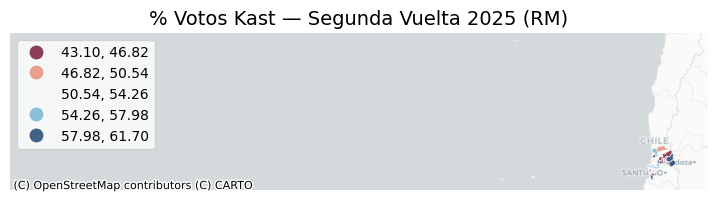

In [5]:
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    column="Pct_Kast",
    cmap="RdBu",
    scheme="EqualInterval",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
contextily.add_basemap(
    ax, crs=db.crs, source=contextily.providers.CartoDB.Positron
)
ax.set_axis_off()
ax.set_title("% Votos Kast — Segunda Vuelta 2025 (RM)", fontsize=14)
plt.show()

El mapa sugiere un patrón espacial: en la V región de Valparaíso las comunas del **interior y precordillera** (Los Andes, San Esteban, Rinconada, San Antonio) tienden a mostrar mayor voto Kast, mientras que las comunas del **litoral central** (Algarrobo, Cartagena, El Quisco) y del **Aconcagua noroeste** (San Felipe, Putaendo, Catemu, LLaillay) muestran voto más favorable a Jara.


## 2.3 Construcción de la matriz de pesos espaciales

In [6]:
# Matriz de k-vecinos más cercanos (k=8)
w = weights.KNN.from_dataframe(db, k=5)
# Estandarización por filas
w.transform = "R"

# 3. Autocorrelación espacial global

## 3.1 Rezago espacial (*Spatial Lag*)

El **rezago espacial** calcula un promedio ponderado de los valores de las comunas vecinas:

$$y_{sl-i} = \sum_j w_{ij} \cdot y_j$$

Esto nos permite comparar el valor de una comuna con el promedio de su vecindario.

In [7]:
# Calcular el rezago espacial del % Kast
db["Pct_Kast_lag"] = weights.spatial_lag.lag_spatial(w, db["Pct_Kast"])

In [8]:
# Comparar comunas con contextos espaciales contrastantes
comunas_interes = db[db["NOM_COMUNA"].isin(
    ["LAS CONDES", "RECOLETA", "VITACURA", "PEDRO AGUIRRE CERDA"]
)]
comunas_interes[["NOM_COMUNA", "Pct_Kast", "Pct_Kast_lag"]]

,NOM_COMUNA,Pct_Kast,Pct_Kast_lag


**San Antonio** (61.7% Kast) y **Los Andes** (60.1% Kast) tienen alto voto Kast y rezagos espaciales también altos — reflejan núcleos de apoyo al candidato. En contraste, **Algarrobo** y **Putaendo** (ambos < 50% Kast) están rodeadas de comunas también con menor voto Kast.


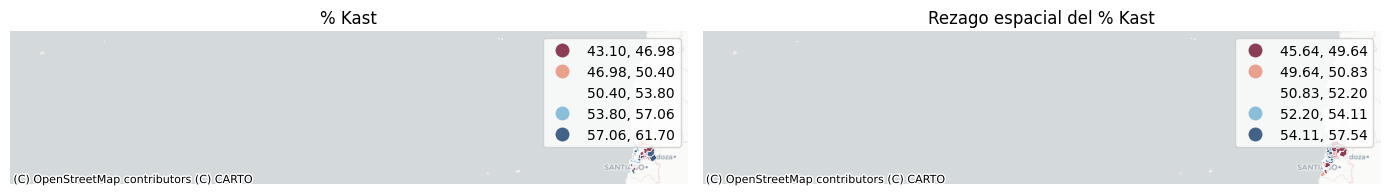

In [9]:
# Mapas lado a lado: valor original vs. rezago espacial
f, axs = plt.subplots(1, 2, figsize=(14, 7))
ax1, ax2 = axs

db.plot(
    column="Pct_Kast",
    cmap="RdBu",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("% Kast")
contextily.add_basemap(
    ax1, crs=db.crs, source=contextily.providers.CartoDB.Positron
)

db.plot(
    column="Pct_Kast_lag",
    cmap="RdBu",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("Rezago espacial del % Kast")
contextily.add_basemap(
    ax2, crs=db.crs, source=contextily.providers.CartoDB.Positron
)

plt.tight_layout()
plt.show()

El mapa de rezago espacial (derecha) suaviza las diferencias abruptas del mapa original. Las transiciones entre zonas pro-Kast y pro-Jara se atenúan, pero el patrón general se mantiene.

## 3.2 Caso binario: *Join Counts*

Los **Join Counts** evalúan la autocorrelación espacial para variables binarias. Codificamos cada comuna como 1 si Kast obtuvo más del 50% de los votos.

In [10]:
# Crear variable binaria: 1 si Kast > 50%
db["Kast_gana"] = (db["Pct_Kast"] > 50).astype(int)
db[["NOM_COMUNA", "Pct_Kast", "Kast_gana"]].tail()

,NOM_COMUNA,Pct_Kast,Kast_gana
33,SANTA MARÍA,45.7,0
34,QUILPUÉ,56.2,1
35,LIMACHE,52.8,1
36,OLMUÉ,57.3,1
37,VILLA ALEMANA,55.5,1


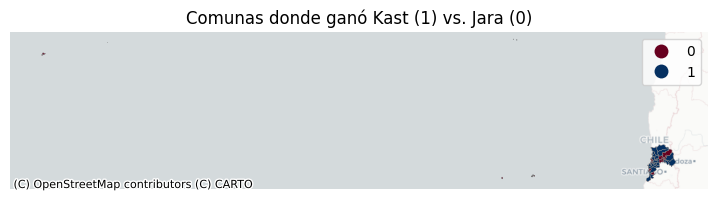

In [11]:
# Mapa de la variable binaria
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    ax=ax,
    column="Kast_gana",
    categorical=True,
    legend=True,
    edgecolor="0.5",
    linewidth=0.25,
    cmap="RdBu",
    figsize=(9, 9),
)
contextily.add_basemap(
    ax, crs=db.crs, source=contextily.providers.CartoDB.Positron
)
ax.set_axis_off()
ax.set_title("Comunas donde ganó Kast (1) vs. Jara (0)")
plt.show()

In [12]:
# Join Counts requiere pesos binarios (no estandarizados)
w.transform = "O"

In [13]:
# Calcular Join Counts
seed(1234)
jc = esda.join_counts.Join_Counts(db["Kast_gana"], w)

In [14]:
# Resultados: conteo de uniones observadas
print(f"Uniones Jara-Jara (0-0): {jc.bb}")
print(f"Uniones Kast-Kast (1-1): {jc.ww}")
print(f"Uniones Jara-Kast (0-1): {jc.bw}")
print(f"Total de uniones: {jc.J}")

Uniones Jara-Jara (0-0): 42.5
Uniones Kast-Kast (1-1): 16.5
Uniones Jara-Kast (0-1): 36.0
Total de uniones: 95.0


In [15]:
# Valores esperados bajo aleatoriedad y pseudo p-valores
print(f"Uniones Jara-Jara esperadas: {jc.mean_bb:.1f}")
print(f"Uniones Jara-Kast esperadas: {jc.mean_bw:.1f}")
print(f"\nP-valor uniones misma categoría: {jc.p_sim_bb:.4f}")
print(f"P-valor uniones distinta categoría: {jc.p_sim_bw:.4f}")

Uniones Jara-Jara esperadas: 40.4
Uniones Jara-Kast esperadas: 44.0

P-valor uniones misma categoría: 0.2600
P-valor uniones distinta categoría: 0.9660


Si los p-valores son significativos, confirman que la distribución espacial del voto no es aleatoria: las comunas pro-Kast tienden a estar junto a otras comunas pro-Kast, y lo mismo para las comunas pro-Jara.

## 3.3 Caso continuo: I de Moran y Gráfico de Moran

El **I de Moran** es el estadístico más utilizado para medir autocorrelación espacial en variables continuas:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} \, z_i \, z_j}{\sum_i z_i^2}$$

Donde $z_i = y_i - \bar{y}$ es el valor centrado en la media.

In [16]:
# Estandarizar la variable (restar la media)
db["Pct_Kast_std"] = db["Pct_Kast"] - db["Pct_Kast"].mean()

# Calcular el rezago espacial de la variable estandarizada
db["Pct_Kast_lag_std"] = weights.lag_spatial(w, db["Pct_Kast_std"])

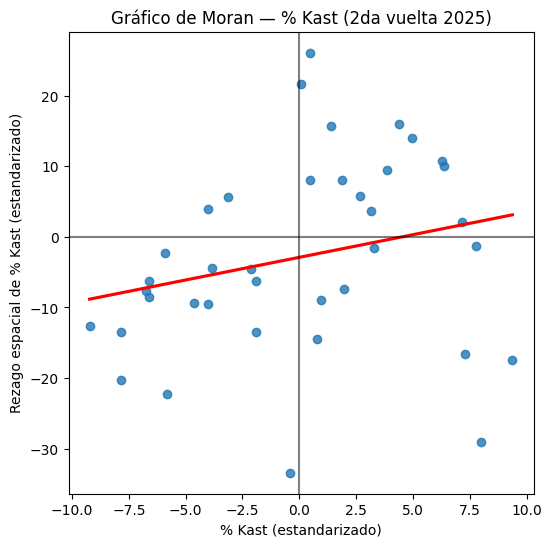

In [17]:
# Gráfico de Moran
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Kast_std",
    y="Pct_Kast_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran — % Kast (2da vuelta 2025)")
ax.set_xlabel("% Kast (estandarizado)")
ax.set_ylabel("Rezago espacial de % Kast (estandarizado)")
plt.show()

Una pendiente positiva en el gráfico de Moran indica **autocorrelación espacial positiva**: comunas con alto (bajo) voto Kast tienden a estar rodeadas de comunas con alto (bajo) voto Kast.

In [18]:
# Calcular I de Moran formalmente
w.transform = "R"
moran = esda.moran.Moran(db["Pct_Kast"], w)

In [19]:
print(f"I de Moran: {moran.I:.4f}")
print(f"Pseudo p-valor: {moran.p_sim:.4f}")

I de Moran: 0.1284
Pseudo p-valor: 0.0520


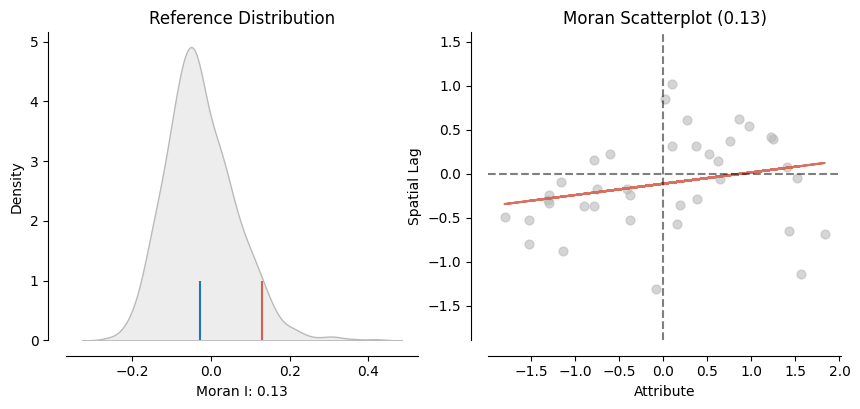

In [20]:
# Visualización combinada con splot
plot_moran(moran);

El panel izquierdo muestra la distribución empírica del I de Moran bajo 999 permutaciones aleatorias. La marca roja indica el valor observado. Si se ubica sustancialmente por encima de la distribución, hay evidencia de autocorrelación espacial positiva significativa.

## 3.4 C de Geary

La **C de Geary** mide la similitud entre vecinos a través de diferencias al cuadrado:

$$C = \frac{(n-1)}{2 \sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} (y_i - y_j)^2}{\sum_i (y_i - \bar{y})^2}$$

- $C < 1$: autocorrelación positiva
- $C = 1$: aleatoriedad
- $C > 1$: autocorrelación negativa

In [21]:
geary = esda.geary.Geary(db["Pct_Kast"], w)

print(f"C de Geary: {geary.C:.4f}")
print(f"Pseudo p-valor: {geary.p_sim:.4f}")

C de Geary: 0.8761
Pseudo p-valor: 0.1060


Un valor de C significativamente menor que 1 confirma autocorrelación espacial positiva, consistente con los resultados del I de Moran.

## 3.5 G de Getis y Ord

El estadístico **G** mide la concentración de valores altos o bajos:

$$G(d) = \frac{\sum_i \sum_j w_{ij}(d) \, y_i \, y_j}{\sum_i \sum_j y_i \, y_j}$$

In [22]:
# Reproyectar a UTM zona 19S (EPSG:32719) para distancias en metros
db_utm = db.to_crs(epsg=32719)

# Distancia mínima umbral
pts = db_utm.centroid
xys = pandas.DataFrame({"X": pts.x, "Y": pts.y})
min_thr = weights.util.min_threshold_distance(xys)
print(f"Distancia umbral mínima: {min_thr:.1f} metros")

Distancia umbral mínima: 3184083.2 metros


In [23]:
# Pesos de banda de distancia
w_db = weights.DistanceBand.from_dataframe(db_utm, min_thr)

In [24]:
# G de Getis y Ord
gao = esda.getisord.G(db["Pct_Kast"].values, w_db)

print(f"G de Getis-Ord: {gao.G:.4f}")
print(f"Pseudo p-valor: {gao.p_sim:.4f}")

G de Getis-Ord: 0.9531
Pseudo p-valor: 0.2550


Un p-valor significativo indica que los valores de voto Kast no se distribuyen aleatoriamente en el espacio, sino que muestran patrones de concentración.

# 4. Resumen

| Estadístico | Tipo de variable | Qué mide | Valor de referencia |
|-------------|-----------------|----------|-----------------------|
| Join Counts | Binaria | Agrupación de categorías (Kast/Jara) | Esperado bajo aleatoriedad |
| I de Moran | Continua | Correlación espacial global | $I = 0$ (sin autocorrelación) |
| C de Geary | Continua | Similitud entre vecinos | $C = 1$ (aleatoriedad) |
| G de Getis-Ord | Continua (positiva) | Concentración de valores | Esperado bajo aleatoriedad |

Los resultados permiten evaluar si la distribución espacial del voto en la Región Metropolitana presenta patrones significativos de agrupamiento, o si podría ser producto del azar.

# 5. Preguntas de estudio

1. Repite el análisis completo usando `Pct_Jara` en lugar de `Pct_Kast`:
   - a) ¿Obtienes los mismos resultados de autocorrelación? ¿Por qué?
   - b) Compara los gráficos de Moran de ambas variables.

2. Modifica el número de vecinos en la matriz de pesos (prueba con k=4 y k=12):
   - a) ¿Cómo cambian los valores del I de Moran?
   - b) ¿Los resultados son robustos al cambio de k?

3. Investiga comunas específicas:
   - a) Identifica comunas donde el valor observado y el rezago espacial están en cuadrantes opuestos del gráfico de Moran (outliers espaciales).
   - b) ¿Qué factores podrían explicar estas discrepancias?